# Test — evaluation on MIT1003

Evaluates a trained checkpoint on **MIT1003**, our held-out test set.
Since models are trained on SALICON, this is a **cross-dataset** evaluation: it measures generalization to real eye-tracking data.

- Loads the newest `checkpoints/best_model_<experiment>_*.pth` (or set `CKPT_PATH` manually).
- Computes the metrics registered in `config.py` (PCC, JSS, MSE) with the same `validate()` used during training.
- Produces the qualitative figure (image | prediction | ground truth) for the report.
  Sample indices are fixed so the same figure is comparable across models.

In [1]:
import os, glob
import torch
import numpy as np
import matplotlib.pyplot as plt

from config import get_config
from models import build_model
from losses import build_loss
from metrics import build_metrics
from data import create_mit_test_loader
from train import validate

# ---- settings ----
EXPERIMENT = "baseline"
CKPT_PATH = None          # None -> newest matching checkpoint in checkpoints/
SAVE_PLOTS = True
PLOT_DIR = "plots"

config = get_config(EXPERIMENT)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

if CKPT_PATH is None:
    ckpts = sorted(glob.glob(f"checkpoints/best_model_{EXPERIMENT}_*.pth"), key=os.path.getmtime)
    assert ckpts, f"No checkpoint found for '{EXPERIMENT}' in checkpoints/"
    CKPT_PATH = ckpts[-1]

model = build_model(config.model).to(device)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
print(f"Loaded checkpoint: {CKPT_PATH}")

SaliencyDataset class defined.

--- Data Preparation Complete ---


Using device: cuda


/home/gica2600/miniconda3/envs/nndl_saliency/lib/python3.10/site-packages/torch/cuda/__init__.py:230: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_37 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(
/tmp/ipykernel_134566/1267570790.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This

Loaded checkpoint: checkpoints/best_model_baseline_20260709_103539.pth


In [2]:
# ---- quantitative evaluation on MIT1003 ----
test_loader = create_mit_test_loader(config)
criterion = build_loss(config.loss).to(device)
metrics = build_metrics(config.metrics)

results = validate(model, test_loader, criterion, metrics, device)
results["test_loss"] = results.pop("val_loss")  # rename: this is the test set

print(f"\n--- Test results on MIT1003 ({len(test_loader.dataset)} images) | {EXPERIMENT} ---")
for k, v in results.items():
    print(f"{k:10s}: {v:.4f}")

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

Validating:   3%|▎         | 1/32 [00:02<01:29,  2.89s/it]

Validating:   6%|▋         | 2/32 [00:03<00:39,  1.33s/it]

Validating:   9%|▉         | 3/32 [00:03<00:24,  1.21it/s]

Validating:  12%|█▎        | 4/32 [00:03<00:16,  1.69it/s]

...

Validating:  62%|██████▎   | 20/32 [00:07<00:02,  4.82it/s]

Validating:  66%|██████▌   | 21/32 [00:07<00:02,  4.81it/s]

Validating:  69%|██████▉   | 22/32 [00:07<00:02,  4.84it/s]

Validating: 100%|██████████| 32/32 [00:06<00:00,  4.59it/s]


--- Test results on MIT1003 (1003 images) | baseline ---
PCC       : 0.6321
JSS       : 0.7259
MSE       : 0.0203
test_loss : 0.0203


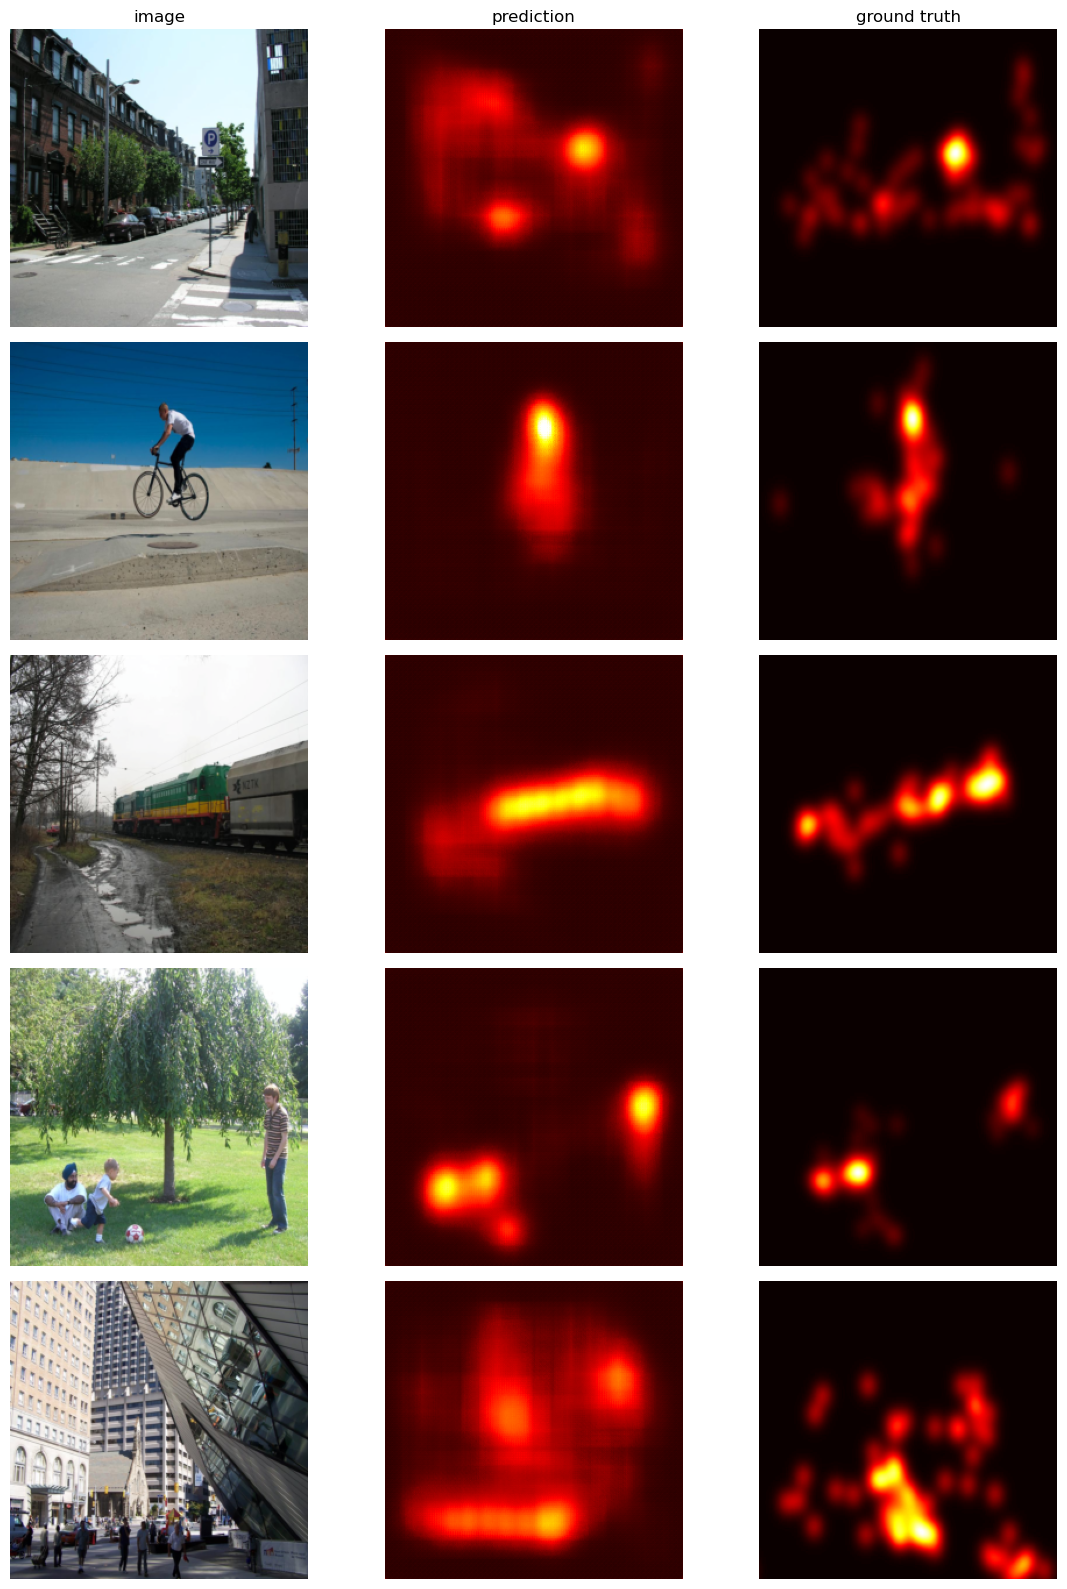

In [3]:
# ---- qualitative results: image | prediction | ground truth ----
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])
sample_idxs = [0, 150, 300, 450, 600]   # fixed -> comparable across models

ds = test_loader.dataset
fig, axes = plt.subplots(len(sample_idxs), 3, figsize=(12, 3.2 * len(sample_idxs)))

for row, idx in enumerate(sample_idxs):
    image, gt = ds[idx]
    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device)).squeeze().cpu().numpy()
    img_np = np.clip(image.permute(1, 2, 0).numpy() * STD + MEAN, 0, 1)  # undo ImageNet normalization

    axes[row, 0].imshow(img_np)
    axes[row, 1].imshow(pred, cmap="hot", vmin=0, vmax=1)
    axes[row, 2].imshow(gt.squeeze().numpy(), cmap="hot", vmin=0, vmax=1)
    for ax in axes[row]:
        ax.axis("off")

for col, title in enumerate(["image", "prediction", "ground truth"]):
    axes[0, col].set_title(title)

plt.tight_layout()
if SAVE_PLOTS:
    os.makedirs(PLOT_DIR, exist_ok=True)
    plt.savefig(os.path.join(PLOT_DIR, f"test_{EXPERIMENT}_qualitative.png"), dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# ---- save ALL prediction maps to output/<model_name>/ ----
# One folder per model (output/BaselineCNN, output/MultiScaleCNN, ...):
# lets us compare models qualitatively and re-score maps without re-running them.
from PIL import Image
from tqdm import tqdm

OUT_DIR = os.path.join("output", config.model.name)
os.makedirs(OUT_DIR, exist_ok=True)

ds = test_loader.dataset
i = 0
with torch.no_grad():
    for images, _ in tqdm(test_loader, desc="Saving predictions"):
        preds = model(images.to(device)).cpu().numpy()  # (B,1,256,256)
        for p in preds:
            fname = ds.image_files[i]  # loader has shuffle=False -> order matches
            base = os.path.splitext(fname)[0]
            # resize back to the original stimulus size -> comparable with
            # ALLFIXATIONMAPS files and usable by external benchmark code
            orig_size = Image.open(os.path.join(ds.image_dir, fname)).size  # (W,H)
            pm = Image.fromarray((p[0] * 255).astype(np.uint8), mode="L")
            pm = pm.resize(orig_size, Image.BILINEAR)
            pm.save(os.path.join(OUT_DIR, base + ".png"))
            i += 1

print(f"Saved {i} prediction maps to {OUT_DIR}/")

Saving predictions:   0%|          | 0/32 [00:00<?, ?it/s]

Saving predictions:   3%|▎         | 1/32 [00:01<00:57,  1.85s/it]

Saving predictions:   6%|▋         | 2/32 [00:02<00:36,  1.21s/it]

Saving predictions:   9%|▉         | 3/32 [00:03<00:29,  1.01s/it]

Saving predictions:  12%|█▎        | 4/32 [00:04<00:25,  1.10it/s]

...

Saving predictions:  94%|█████████▍| 30/32 [00:23<00:01,  1.33it/s]

Saving predictions:  97%|█████████▋| 31/32 [00:24<00:00,  1.32it/s]

Saving predictions: 100%|██████████| 32/32 [00:24<00:00,  1.62it/s]

Saving predictions: 100%|██████████| 32/32 [00:24<00:00,  1.29it/s]

Saved 1003 prediction maps to output/BaselineCNN/
